In [ ]:
# Uncomment if running on colab

In [ ]:
import deeptrack as dt
import optuna # Install optuna beforehand
import numpy as np
import random
from matplotlib import pyplot as plt

In [ ]:
# Aberration types that can be simulated in DeepTrack2.
aberration_types = [
    dt.Piston,
    dt.VerticalTilt,
    dt.HorizontalTilt,
    dt.ObliqueAstigmatism,
    dt.Defocus,
    dt.Astigmatism,
    dt.ObliqueTrefoil,
    dt.VerticalComa,
    dt.HorizontalComa,
    dt.Trefoil,
    dt.SphericalAberration
]

Coefficient: -1.8500331613112628
Radius: 1e-06


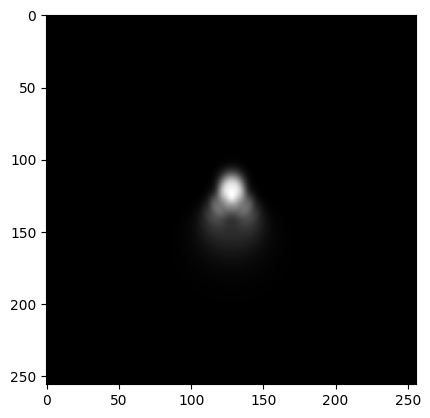

In [ ]:
IMAGE_SIZE=256

optics = dt.Fluorescence(
    output_region=(0, 0, IMAGE_SIZE, IMAGE_SIZE)
)

# Pick a random aberration.
aberration = random.choice(aberration_types)

# Randomize the aberration strength.
aberration = aberration(
    coefficient=lambda: (2 * np.random.rand() - 1) * 8
)

# Modify the pupil of the microscope.
optics.pupil = aberration

# Define scatterer.
particle = dt.Sphere(
    position=(IMAGE_SIZE//2, IMAGE_SIZE//2, 0 ),
    radius=1e-6
)

# Image the scatterer through the aberrated microscope.
experimental_image = optics(particle).resolve().squeeze()

plt.imshow(experimental_image, cmap="gray")
print(f"{aberration}")
print(f"Coefficient: {aberration.coefficient()}")
print(f"Radius: {particle.radius()}")

In [ ]:
IMAGE_SIZE = 256

# Define microscope.
optics = dt.Fluorescence(
    output_region=(0, 0, IMAGE_SIZE, IMAGE_SIZE)
)

# Simulation function.
def simulate_aberrated_image(
        aberration_class,
        coefficient,
        radius,
        focal_distance
):
    aberration = aberration_class
    simulated_aberration = aberration(coefficient=coefficient)

    optics.pupil = simulated_aberration
    particle = dt.Sphere(
        radius=radius,
        position=(IMAGE_SIZE // 2, IMAGE_SIZE // 2, focal_distance)
    )
    simulated_image = optics(particle).resolve().squeeze()
    return simulated_image.astype(np.float32)

# Objective function, this defines the search parameters and loss function.
def objective(trial):

    # Varies aberration type.
    aberration_name = trial.suggest_categorical(
        "aberration_name", [cls.__name__ for cls in aberration_types]
    )
    aberration_class = next(
        cls for cls in aberration_types if cls.__name__ == aberration_name
    )

    coefficient = trial.suggest_float("coefficient", -10, 10) # Explores aberration strength.
    radius = trial.suggest_float("radius", 1e-7, 2.1e-6) # Explores particle radius.
    focal_distance = trial.suggest_float("focal_distance", -1, 1) # Explores focal distance (defocusing).

    simulated_image = simulate_aberrated_image(
        aberration_class,
        coefficient,
        radius,
        focal_distance,
    )

    loss = np.sqrt(np.mean(np.square(simulated_image - experimental_image) ))
    return loss

# Run Optuna optimization
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=200)

print("Best RSME:", study.best_value)
print("Best parameters:", study.best_trial.params)


[I 2025-04-25 15:36:13,118] A new study created in memory with name: no-name-75ad74ed-fd7a-44dc-9356-f3675ea8bb7e
[I 2025-04-25 15:36:13,215] Trial 0 finished with value: 0.011924629097666494 and parameters: {'aberration_name': 'SphericalAberration', 'coefficient': -3.599555380328461, 'radius': 1.2293279626741794e-07, 'focal_distance': -0.6241153403385722}. Best is trial 0 with value: 0.011924629097666494.
[I 2025-04-25 15:36:13,774] Trial 1 finished with value: 0.008264094594325755 and parameters: {'aberration_name': 'ObliqueTrefoil', 'coefficient': -9.729524622473193, 'radius': 1.4475929836328102e-06, 'focal_distance': 0.7500847206507499}. Best is trial 1 with value: 0.008264094594325755.
[I 2025-04-25 15:36:14,064] Trial 2 finished with value: 0.010183985930607957 and parameters: {'aberration_name': 'ObliqueTrefoil', 'coefficient': 6.928997586137616, 'radius': 7.693772929962083e-07, 'focal_distance': -0.411821807566483}. Best is trial 1 with value: 0.008264094594325755.
[I 2025-04-2

Best RSME: 0.0021416291524758223
Best parameters: {'aberration_name': 'VerticalComa', 'coefficient': 2.5518046080183736, 'radius': 9.854557858913137e-07, 'focal_distance': 0.847885851248093}


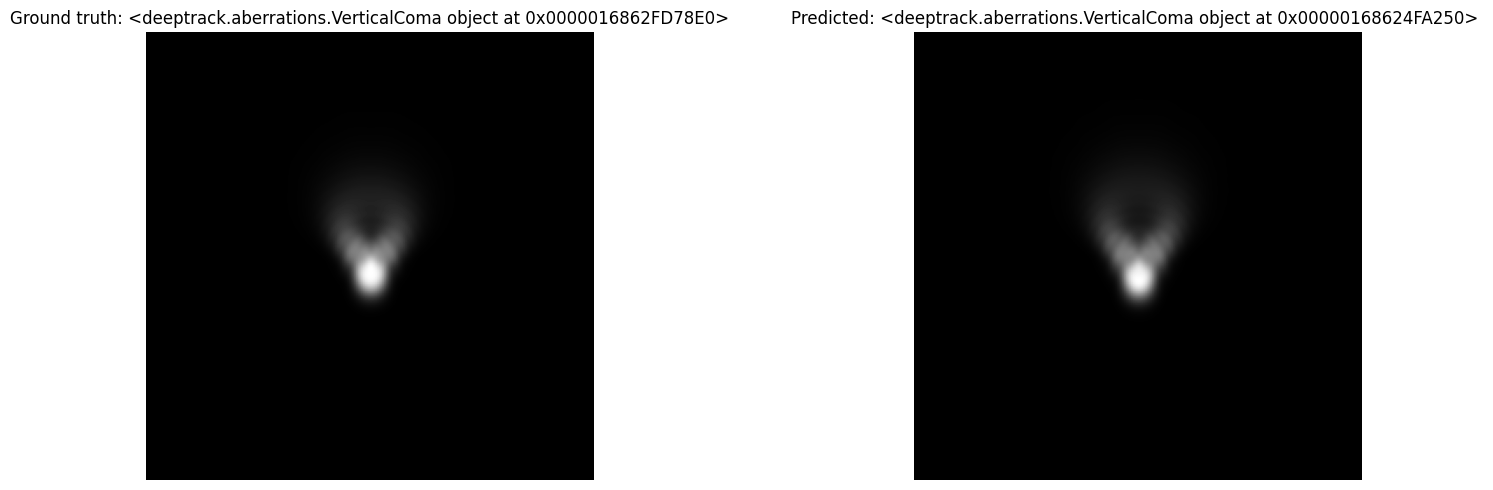

{'aberration_name': 'VerticalComa', 'coefficient': 2.5518046080183736, 'radius': 9.854557858913137e-07, 'focal_distance': 0.847885851248093}


In [ ]:
# Get best parameters from the study.
best_params = study.best_trial.params
coeff = best_params["coefficient"]

# Reconstruct the image which had the optimal parameters.
predicted_aberration = study.best_params["aberration_name"]

# Convert string back to class.
aberration_class = next(cls for cls in aberration_types if cls.__name__ == predicted_aberration)

# Create aberration instance.
predicted_aberration = aberration_class(coefficient=coeff)

optics.pupil = predicted_aberration
predicted_particle = dt.Sphere(
    radius=best_params["radius"],
    position=(IMAGE_SIZE // 2, IMAGE_SIZE // 2, best_params["focal_distance"])
)

# Generate predicted image.
predicted_image = optics(predicted_particle).resolve().squeeze()

fig, ax = plt.subplots(1, 2, figsize=(18, 5))
ax[0].imshow(experimental_image, cmap="gray")
ax[0].set_title(f"Ground truth: {aberration}")
ax[0].axis("off")

ax[1].imshow(predicted_image, cmap="gray")
ax[1].set_title(f"Predicted: {predicted_aberration} ")
ax[1].axis("off")

plt.tight_layout()
plt.show()
print(best_params)